# EDA 可视化内容说明（2017-2020 合并数据）

本 Notebook 主要可视化以下内容：
1. 用户画像与借阅活跃度（学院 Top10、读者类型占比）
2. 图书热度与学科分布（热门图书 Top10、中图法大类）
3. 时间趋势分析（按月份、按星期）
4. 学科-时段分析（趋势折线图、热力图）
5. 借阅时长分布（直方图 + KDE）
6. 图书借阅共现分析（共现组合 Top12）


In [15]:
import os
from pathlib import Path
from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd
import seaborn as sns

def pick_chinese_font():
    preferred = [
        'Microsoft YaHei',
        'SimHei',
        'Noto Sans CJK SC',
        'Source Han Sans SC',
        'WenQuanYi Zen Hei'
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    return None

chosen_font = pick_chinese_font()
font_list = [chosen_font] if chosen_font else ['DejaVu Sans']

# 先在 seaborn 主题中写入字体，避免 set_theme 覆盖 rcParams
sns.set_theme(
    style='whitegrid',
    rc={
        'font.family': 'sans-serif',
        'font.sans-serif': font_list,
        'axes.unicode_minus': False
    }
)

# 再次强制，确保 matplotlib 直接调用也使用中文字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = font_list
plt.rcParams['axes.unicode_minus'] = False

def resolve_processed_dir():
    candidates = [Path('data/processed'), Path('../data/processed')]
    for p in candidates:
        if (p / 'users_2017_2020.csv').exists() and (p / 'books_2017_2020.csv').exists() and (p / 'borrows_2017_2020.csv').exists():
            return p
    raise FileNotFoundError('未找到 data/processed 或 ../data/processed 下的三张表文件')

processed_dir = resolve_processed_dir()
images_dir = processed_dir / 'images'
images_dir.mkdir(parents=True, exist_ok=True)

users = pd.read_csv(processed_dir / 'users_2017_2020.csv', low_memory=False)
books = pd.read_csv(processed_dir / 'books_2017_2020.csv', low_memory=False)
borrows = pd.read_csv(processed_dir / 'borrows_2017_2020.csv', low_memory=False)

borrows['LEND_DATE'] = pd.to_datetime(borrows['LEND_DATE'], errors='coerce')
borrows['RET_DATE'] = pd.to_datetime(borrows['RET_DATE'], errors='coerce')
borrows['LEND_DAYS'] = (borrows['RET_DATE'] - borrows['LEND_DATE']).dt.total_seconds() / (24 * 3600)
borrows['LEND_MONTH'] = borrows['LEND_DATE'].dt.month
borrows['LEND_HOUR'] = borrows['LEND_DATE'].dt.hour
borrows['LEND_DAYOFWEEK'] = borrows['LEND_DATE'].dt.dayofweek + 1

df = borrows.merge(users, on='USERID', how='left').merge(books, on='BOOK_ID', how='left')
print('processed_dir =', processed_dir)
print('font =', chosen_font if chosen_font else 'fallback: DejaVu Sans')
print('merged rows:', df.shape[0], 'cols:', df.shape[1])


processed_dir = ..\data\processed
font = Microsoft YaHei
merged rows: 304293 cols: 27


C:\Users\86138\AppData\Local\Temp\ipykernel_8552\2841049093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.values, y=dept_counts.index, palette='viridis', ax=axes[0])


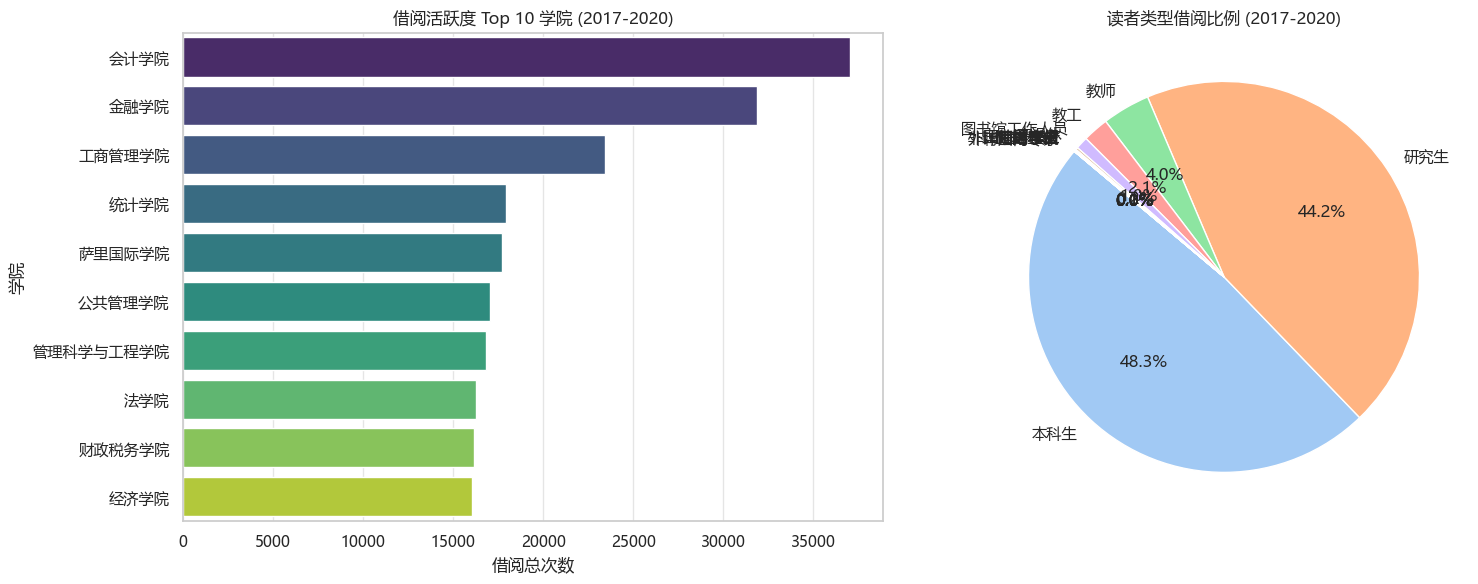

In [16]:
# 1) 用户画像与借阅活跃度
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dept_counts = df[df['DEPT'].notna() & (df['DEPT'] != 'Unknown')]['DEPT'].value_counts().head(10)
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette='viridis', ax=axes[0])
axes[0].set_title('借阅活跃度 Top 10 学院 (2017-2020)')
axes[0].set_xlabel('借阅总次数')
axes[0].set_ylabel('学院')

reader_counts = df['REDR_TYPE_NAME'].fillna('Unknown').value_counts()
axes[1].pie(reader_counts.values, labels=reader_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=140)
axes[1].set_title('读者类型借阅比例 (2017-2020)')

plt.tight_layout()
plt.savefig(images_dir / 'eda_user_profile.png', dpi=300)
plt.show()


C:\Users\86138\AppData\Local\Temp\ipykernel_8552\2650953498.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=book_counts.values, y=book_counts.index, palette='magma', ax=axes[0])
C:\Users\86138\AppData\Local\Temp\ipykernel_8552\2650953498.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subject_counts.index, y=subject_counts.values, palette='crest', ax=axes[1])


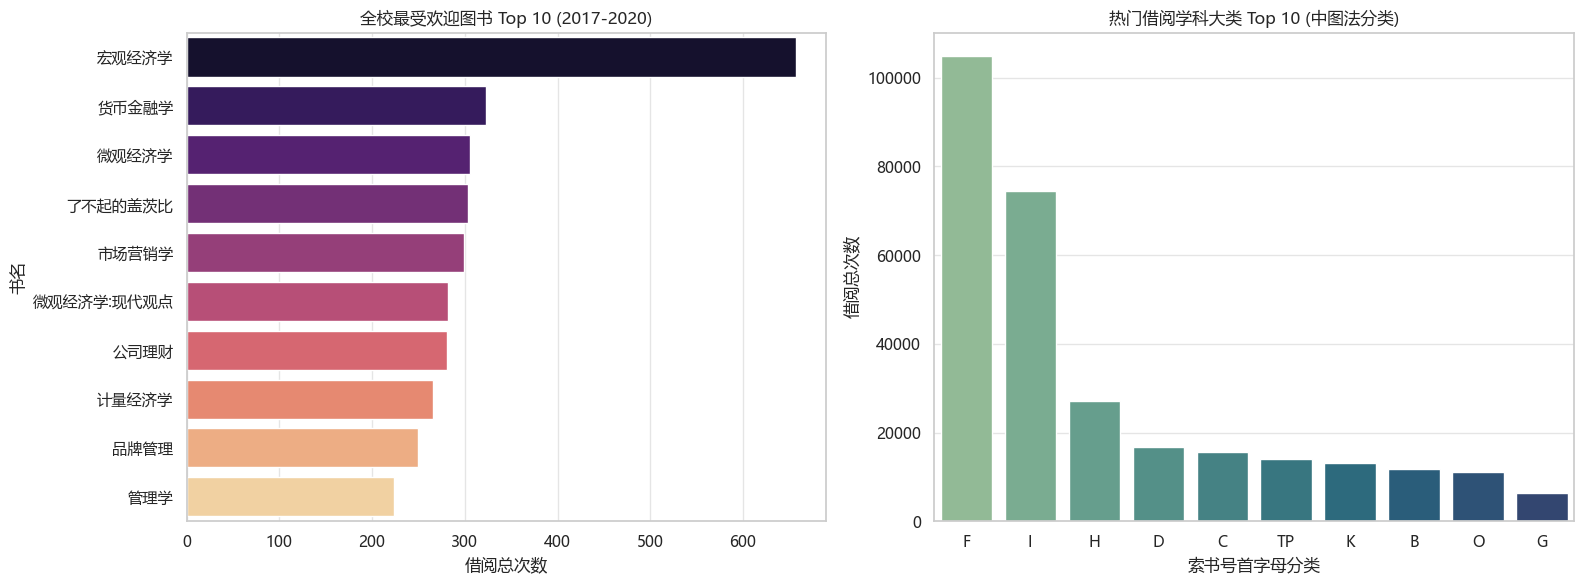

In [17]:
# 2) 图书热度与学科分布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

book_counts = df[df['TITLE'].notna()]['TITLE'].value_counts().head(10)
sns.barplot(x=book_counts.values, y=book_counts.index, palette='magma', ax=axes[0])
axes[0].set_title('全校最受欢迎图书 Top 10 (2017-2020)')
axes[0].set_xlabel('借阅总次数')
axes[0].set_ylabel('书名')

subject = df['CALL_NO'].astype(str).str.extract(r'([A-Za-z]+)')[0]
subject_counts = subject.value_counts().head(10)
sns.barplot(x=subject_counts.index, y=subject_counts.values, palette='crest', ax=axes[1])
axes[1].set_title('热门借阅学科大类 Top 10 (中图法分类)')
axes[1].set_xlabel('索书号首字母分类')
axes[1].set_ylabel('借阅总次数')

plt.tight_layout()
plt.savefig(images_dir / 'eda_book_popularity.png', dpi=300)
plt.show()


C:\Users\86138\AppData\Local\Temp\ipykernel_8552\2662772875.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_labels, y=day_counts.values, palette='coolwarm', ax=axes[1])


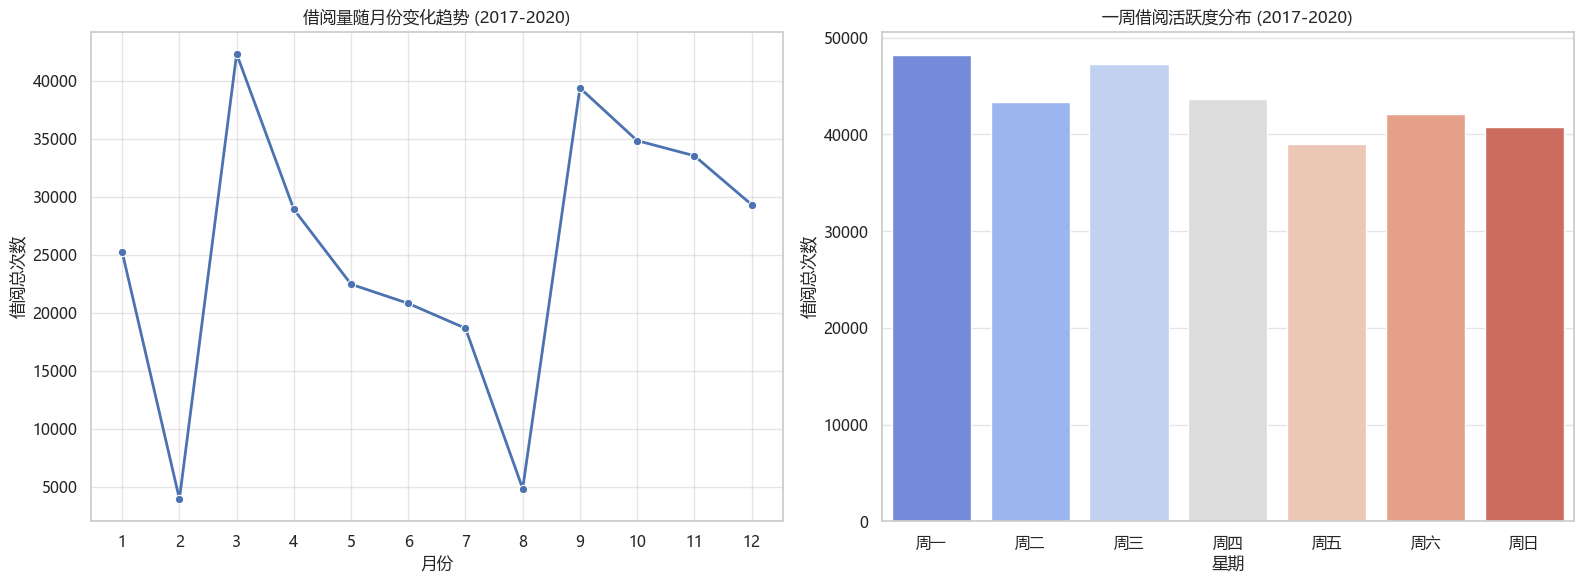

In [18]:
# 3) 时间趋势（月 + 周）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

month_counts = df.groupby('LEND_MONTH').size().sort_index()
sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o', linewidth=2, ax=axes[0])
axes[0].set_title('借阅量随月份变化趋势 (2017-2020)')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('借阅总次数')
axes[0].set_xticks(range(1, 13))

day_counts = df['LEND_DAYOFWEEK'].value_counts().sort_index()
day_labels = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
sns.barplot(x=day_labels, y=day_counts.values, palette='coolwarm', ax=axes[1])
axes[1].set_title('一周借阅活跃度分布 (2017-2020)')
axes[1].set_xlabel('星期')
axes[1].set_ylabel('借阅总次数')

plt.tight_layout()
plt.savefig(images_dir / 'eda_time_trends.png', dpi=300)
plt.show()


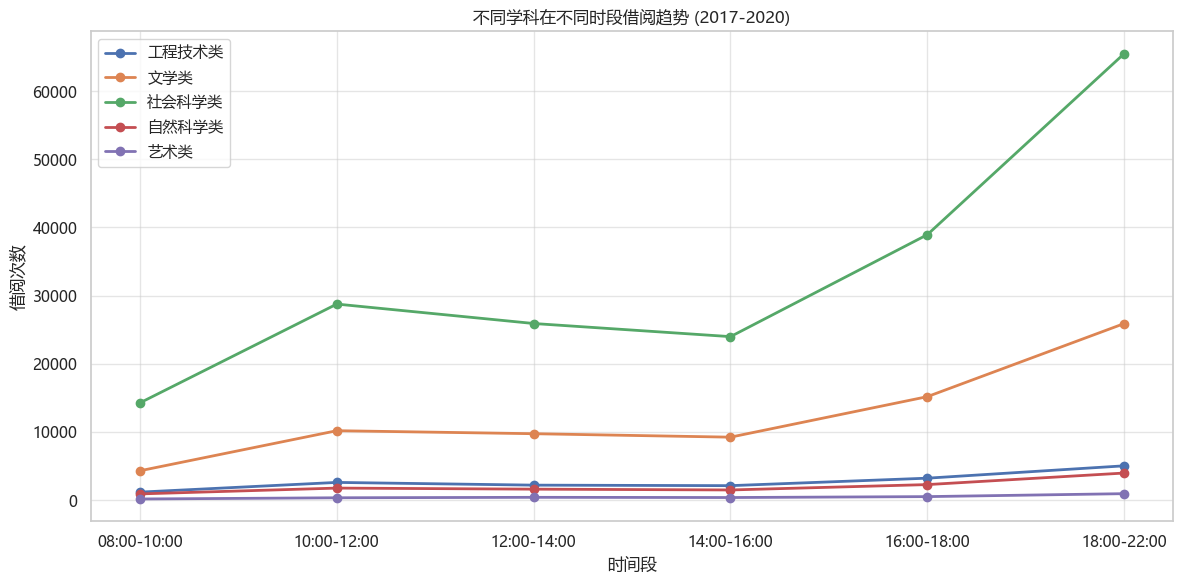

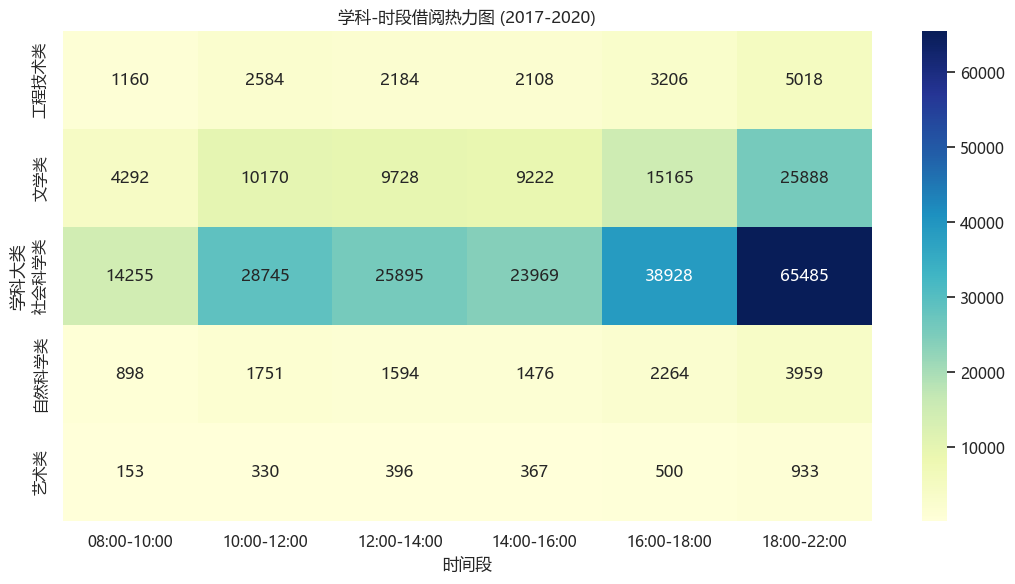

In [19]:
# 4) 学科-时段热力图 + 趋势线
def map_clc_to_broad_category(call_no):
    if pd.isna(call_no) or str(call_no).strip() == '':
        return '其他'
    letter = str(call_no).strip()[0].upper()
    if letter == 'I':
        return '文学类'
    if letter == 'J':
        return '艺术类'
    if letter in ['N', 'O', 'P', 'Q']:
        return '自然科学类'
    if letter in ['T', 'U', 'V', 'X']:
        return '工程技术类'
    if letter in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'K']:
        return '社会科学类'
    return '其他'

tmp = df.copy()
tmp['BROAD_CATEGORY'] = tmp['CALL_NO'].apply(map_clc_to_broad_category)
tmp = tmp[(tmp['LEND_HOUR'] >= 8) & (tmp['LEND_HOUR'] < 22)].copy()

bins = [8, 10, 12, 14, 16, 18, 22]
labels = ['08:00-10:00', '10:00-12:00', '12:00-14:00', '14:00-16:00', '16:00-18:00', '18:00-22:00']
tmp['TIME_PERIOD'] = pd.cut(tmp['LEND_HOUR'], bins=bins, labels=labels, right=False)

pivot_df = pd.crosstab(tmp['BROAD_CATEGORY'], tmp['TIME_PERIOD'])
if '其他' in pivot_df.index:
    pivot_df = pivot_df.drop('其他')

plt.figure(figsize=(12, 6))
for category in pivot_df.index:
    plt.plot(pivot_df.columns, pivot_df.loc[category].values, marker='o', linewidth=2, label=category)
plt.title('不同学科在不同时段借阅趋势 (2017-2020)')
plt.xlabel('时间段')
plt.ylabel('借阅次数')
plt.legend()
plt.tight_layout()
plt.savefig(images_dir / 'eda_borrowing_trend_line.png', dpi=300)
plt.show()

plt.figure(figsize=(11, 6))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='YlGnBu')
plt.title('学科-时段借阅热力图 (2017-2020)')
plt.xlabel('时间段')
plt.ylabel('学科大类')
plt.tight_layout()
plt.savefig(images_dir / 'eda_behavior_heatmap.png', dpi=300)
plt.show()


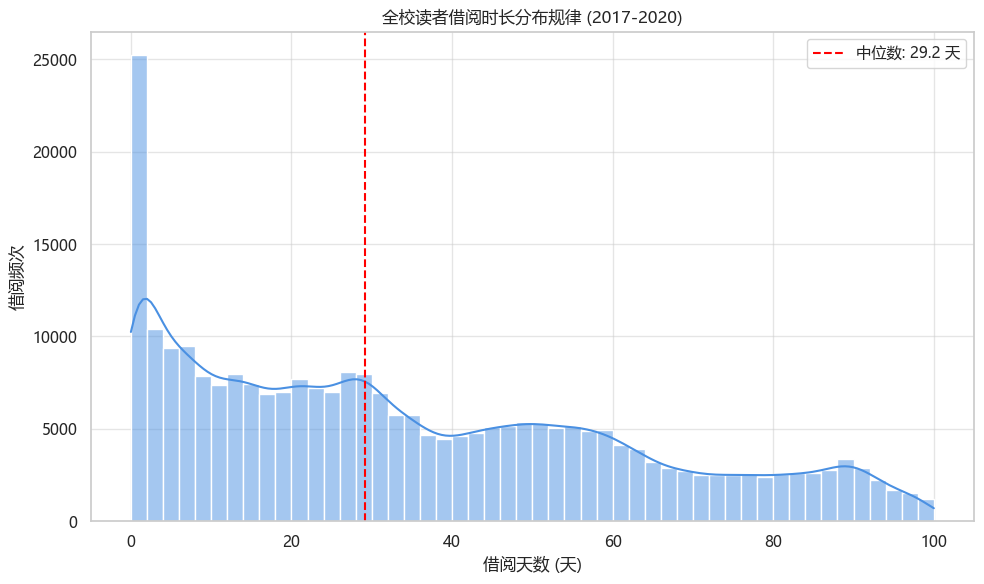

In [20]:
# 5) 借阅时长分布
valid_days = df[(df['LEND_DAYS'] > 0) & (df['LEND_DAYS'] < 100)]['LEND_DAYS']

plt.figure(figsize=(10, 6))
sns.histplot(valid_days, bins=50, kde=True, color='#4A90E2', edgecolor='white')
plt.title('全校读者借阅时长分布规律 (2017-2020)')
plt.xlabel('借阅天数 (天)')
plt.ylabel('借阅频次')
if len(valid_days) > 0:
    plt.axvline(valid_days.median(), color='red', linestyle='--', label=f'中位数: {valid_days.median():.1f} 天')
    plt.legend()
plt.tight_layout()
plt.savefig(images_dir / 'eda_lend_days_dist.png', dpi=300)
plt.show()


C:\Users\86138\AppData\Local\Temp\ipykernel_8552\1465486804.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pair_counts, y=pair_names, palette='viridis')


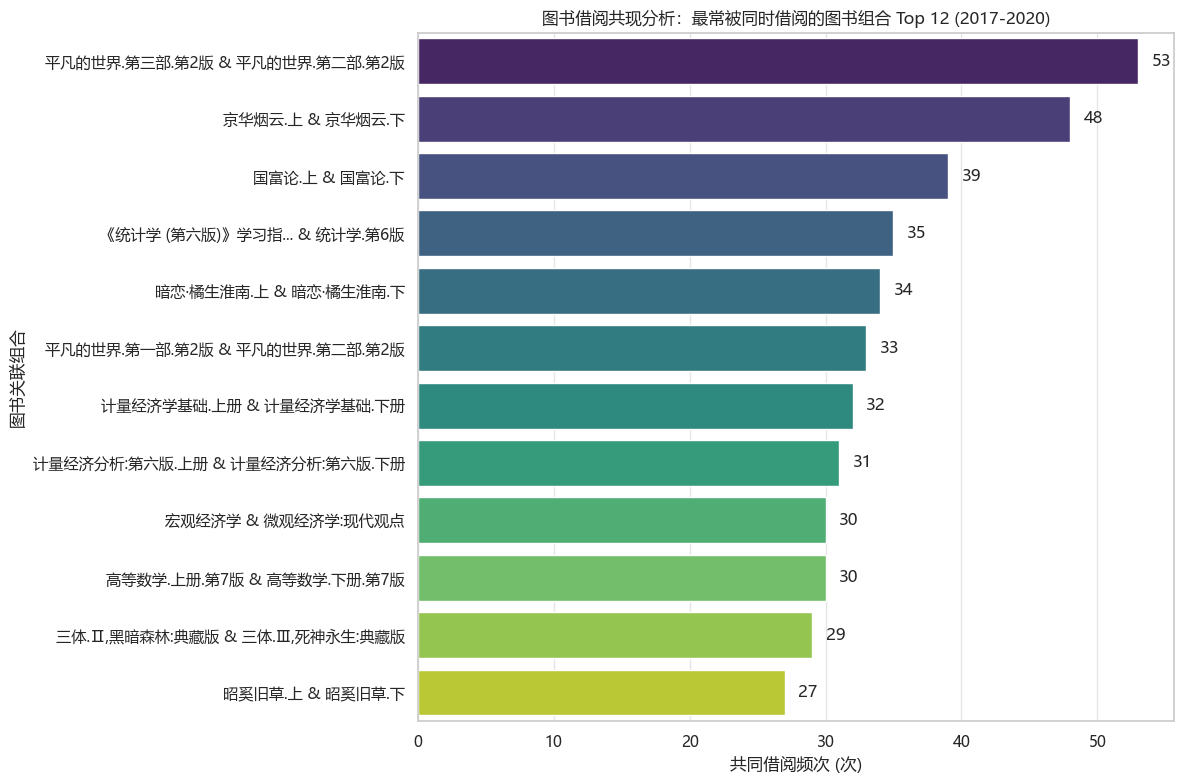

EDA 图表已更新完成，输出目录: ..\data\processed\images


In [21]:
# 6) 图书借阅共现分析 Top 12
co = df.dropna(subset=['TITLE']).copy()
co['LEND_DATE_ONLY'] = pd.to_datetime(co['LEND_DATE'], errors='coerce').dt.date
basket_df = co.groupby(['USERID', 'LEND_DATE_ONLY'])['TITLE'].apply(lambda x: list(set(x))).reset_index()
baskets = basket_df[basket_df['TITLE'].apply(len) > 1]['TITLE'].tolist()

pair_counter = Counter()
for basket in baskets:
    pair_counter.update(combinations(sorted(basket), 2))

top_pairs = pair_counter.most_common(12)

def truncate_title(title, max_len=14):
    return title if len(title) <= max_len else title[:max_len] + '...'

pair_names = [f"{truncate_title(p[0][0])} & {truncate_title(p[0][1])}" for p in top_pairs]
pair_counts = [p[1] for p in top_pairs]

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=pair_counts, y=pair_names, palette='viridis')
plt.title('图书借阅共现分析：最常被同时借阅的图书组合 Top 12 (2017-2020)')
plt.xlabel('共同借阅频次 (次)')
plt.ylabel('图书关联组合')
for i, v in enumerate(pair_counts):
    ax.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.savefig(images_dir / 'eda_book_cooccurrence.png', dpi=300)
plt.show()

print('EDA 图表已更新完成，输出目录:', images_dir)
